In [1]:
!pip install monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.4 MB/s eta 0:00:00


In [2]:
import os
import torch
import numpy as np
import nibabel as nib
import glob
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose, ScaleIntensityRange, Resize, EnsureType
)

class Kaggle_BTCV_Liver_Dataset(Dataset):
    def __init__(self, volume_paths, label_paths):
        """
        Memory-efficient Dataset for extracting Liver (Label 6) slices 
        from BTCV for the Segment Anything Model (SAM).
        """
        self.volume_paths = volume_paths
        self.label_paths = label_paths
        
        # 1. Map out all valid slices without loading full volumes into RAM
        self.valid_slices_map = []
        
        print("Scanning BTCV volumes for Liver (Label 6) slices...")
        for vol_idx, (v_path, l_path) in enumerate(zip(volume_paths, label_paths)):
            # Load only the label volume to find where the liver is
            lab_data = nib.load(l_path).get_fdata()
            depth = lab_data.shape[2]
            
            for slice_idx in range(depth):
                # In BTCV, the liver is encoded as integer 6
                lbl_slice = lab_data[:, :, slice_idx]
                
                # If there are any liver pixels in this slice, record its location
                if np.any(lbl_slice == 6):
                    self.valid_slices_map.append({
                        'vol_idx': vol_idx,
                        'slice_idx': slice_idx
                    })
        
        print(f"Total valid liver slices found: {len(self.valid_slices_map)}")

        # 2. Define the MONAI preprocessing math (from the MoSE paper)
        self.transforms = Compose([
            ScaleIntensityRange(a_min=-200, a_max=400, b_min=0.0, b_max=1.0, clip=True),
            Resize(spatial_size=(384, 384)), 
            EnsureType(dtype=torch.float32)
        ])

    def __len__(self):
        return len(self.valid_slices_map)

    def __getitem__(self, idx):
        # 3. Lazy Loading: Only load the specific volume when needed
        mapping = self.valid_slices_map[idx]
        v_path = self.volume_paths[mapping['vol_idx']]
        l_path = self.label_paths[mapping['vol_idx']]
        slice_idx = mapping['slice_idx']
        
        # We use memory-mapping (mmap) or fast indexing to pull just the slice we need
        vol_data = nib.load(v_path).dataobj
        lab_data = nib.load(l_path).dataobj
        
        # Extract the specific 2D slice
        img_slice = np.array(vol_data[..., slice_idx])
        lbl_slice_raw = np.array(lab_data[..., slice_idx])
        
        # 4. ISOLATE THE LIVER: Convert Label 6 to 1 (Foreground), everything else to 0 (Background)
        lbl_slice = np.where(lbl_slice_raw == 6, 1.0, 0.0)
        
        # Add channel dimension so MONAI can process it: Shape becomes (1, H, W)
        img_slice = img_slice[np.newaxis, ...]
        lbl_slice = lbl_slice[np.newaxis, ...]
        
        # Apply normalization and 384x384 resizing
        img_tensor = self.transforms(img_slice)
        lbl_tensor = self.transforms(lbl_slice)
        
        # 5. TRICK FOR SAM: Convert 1-channel grayscale to 3-channel RGB
        # Shape goes from (1, 384, 384) to (3, 384, 384)
        img_tensor = img_tensor.repeat(3, 1, 1) 
        
        return img_tensor, lbl_tensor

# Use glob to automatically grab lists of all NIfTI files in the directories

# Changed *.nii.gz to *.nii
vol_paths = sorted(glob.glob('/kaggle/input/datasets/nguynhilonguetdhcn/btcv-data-2/01_btcv/images/*.nii'))
lab_paths = sorted(glob.glob('/kaggle/input/datasets/nguynhilonguetdhcn/btcv-data-2/01_btcv/labels/*.nii'))

print(f"Found {len(vol_paths)} volume files and {len(lab_paths)} label files.")

train_ds = Kaggle_BTCV_Liver_Dataset(vol_paths, lab_paths)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)

Found 30 volume files and 30 label files.
Scanning BTCV volumes for Liver (Label 6) slices...
Total valid liver slices found: 1542


--- TENSOR VALIDATION ---
Image Batch Shape: torch.Size([4, 3, 384, 384]) --> Expected: [Batch, 3, 384, 384]
Label Batch Shape: torch.Size([4, 1, 384, 384]) --> Expected: [Batch, 1, 384, 384]
Image Data Type:   torch.float32
Image Range:       Min: 0.00, Max: 1.00 --> Expected: 0.0 to 1.0
Label Values:      [0.3333333432674408, 0.33375000953674316, 0.33416667580604553, 0.3345833420753479, 0.33500000834465027] --> Expected: [0.0, 1.0]

--- VISUAL VALIDATION ---


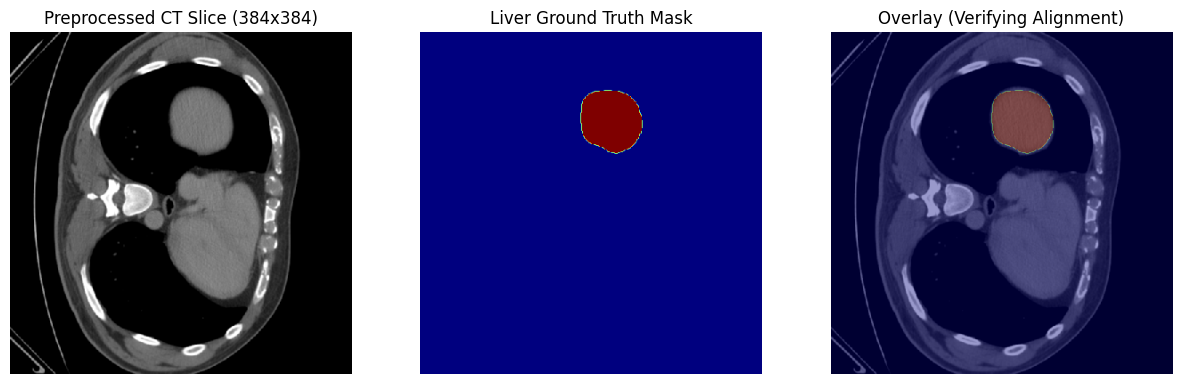

In [3]:
import matplotlib.pyplot as plt
import torch

# 1. Grab a single batch of data from the dataloader
img_batch, lbl_batch = next(iter(train_loader))

# 2. Mathematical & Tensor Shape Validation
print("--- TENSOR VALIDATION ---")
print(f"Image Batch Shape: {img_batch.shape} --> Expected: [Batch, 3, 384, 384]")
print(f"Label Batch Shape: {lbl_batch.shape} --> Expected: [Batch, 1, 384, 384]")
print(f"Image Data Type:   {img_batch.dtype}")
print(f"Image Range:       Min: {img_batch.min().item():.2f}, Max: {img_batch.max().item():.2f} --> Expected: 0.0 to 1.0")
print(f"Label Values:      {torch.unique(lbl_batch).tolist()} --> Expected: [0.0, 1.0]")

# 3. Visual Validation
print("\n--- VISUAL VALIDATION ---")
# Take the first image and label in the batch (index 0)
# We only grab channel 0 of the image because channels 1 and 2 are just identical copies
single_img = img_batch[0, 0, :, :].numpy() 
single_lbl = lbl_batch[0, 0, :, :].numpy()

# Set up a plot with 3 side-by-side images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: The preprocessed CT slice
axes[0].imshow(single_img, cmap='gray')
axes[0].set_title("Preprocessed CT Slice (384x384)")
axes[0].axis('off')

# Plot 2: The binary liver mask
axes[1].imshow(single_lbl, cmap='jet')
axes[1].set_title("Liver Ground Truth Mask")
axes[1].axis('off')

# Plot 3: The overlay (Crucial for verifying alignment)
axes[2].imshow(single_img, cmap='gray')
axes[2].imshow(single_lbl, cmap='jet', alpha=0.4) # Overlay mask with 40% transparency
axes[2].set_title("Overlay (Verifying Alignment)")
axes[2].axis('off')

plt.show()